# Análisis de Reseñas: `dice.fm`
**Sector:** Events & Entertainment

**Objetivos:**
1. ¿Las reseñas de `dice.fm` son mayoritariamente positivas o negativas? ¿Y la competencia?
2. ¿Qué temas tratan las reseñas?
3. Para cada tema, ¿el sentimiento es positivo o negativo? ¿En qué somos mejores/peores?
4. Identificar áreas de mejora


DICE.fm es una plataforma y aplicación móvil líder para la venta de entradas de conciertos y eventos en directo.

## 1. Importación de librerías



In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from transformers import pipeline
from collections import Counter
from wordcloud import WordCloud


## 2. Configuración


In [3]:
MAX_ROWS   = None 
TARGET     = 'dice.fm'
CAT        = 'Events & Entertainment'
N_TOPICS   = 6
TOP_WORDS  = 10
SENT_MODEL = 'lxyuan/distilbert-base-multilingual-cased-sentiments-student'

# Etiquetas de temas — ajustadas tras output NMF (sector Events & Entertainment)
TOPIC_LABELS = {
    0: 'Reembolsos y pagos',
    1: 'Experiencia y ambiente',
    2: 'Fechas y experiencias',      # artefacto NMF — 1 sola reseña en dice.fm
    3: 'Servicio al cliente',
    4: 'Proceso de compra online',
    5: 'Compra de entradas',
}

Modelo multilingüe que devuelve 3 clases: positive, neutral, negative.

## 3. Carga y filtrado de datos


In [4]:
df = pd.read_csv('trustpilot-reviews-123k.csv', encoding = 'utf-8')
if MAX_ROWS:
    df = df.head(MAX_ROWS)
print(f'Filas totales: {len(df):,}')
print(f'Empresas: {df["company"].nunique():,} | Sectores: {df["category"].nunique()}')
df.head(3)

Filas totales: 123,181
Empresas: 1,680 | Sectores: 22


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


In [5]:
sector_df = df[df['category'] == CAT].copy().reset_index(drop=True)
target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)

print(f"Sector '{CAT}': {len(sector_df):,} reseñas | {sector_df['company'].nunique()} empresas")
print(f"Target '{TARGET}': {len(target_df):,} reseñas")
print(f"Competencia: {len(comp_df):,} reseñas | {comp_df['company'].nunique()} empresas")
print(f"\nEmpresas del sector:")
print(sector_df['company'].value_counts().to_string())

Sector 'Events & Entertainment': 5,298 reseñas | 76 empresas
Target 'dice.fm': 100 reseñas
Competencia: 5,198 reseñas | 75 empresas

Empresas del sector:
company
www.shopto.net                      100
www.buyagift.co.uk                  100
www.londontheatre.co.uk             100
omaze.co.uk                         100
www.redletterdays.co.uk             100
www.lovetheatre.com                 100
www.fanatical.com                   100
www.ticketmaster.co.uk              100
www.atgtickets.com                  100
www.twickets.live                   100
www.virginexperiencedays.co.uk      100
www.funkypigeon.com                 100
www.attractiontickets.com           100
www.seetickets.com                  100
www.lovehoney.co.uk                 100
seatunique.com                      100
www.gigsandtours.com                100
dice.fm                             100
fanpass.co.uk                       100
stubhub.co.uk                       100
www.ents24.com                      10

## 4. Exploración inicial (EDA)


  Antes de entrar en los modelos NLP hacemos una inspección estructural del dataset: tipos de datos, tamaños y valores
  nulos. Esto nos confirma con qué columnas vamos a trabajar y qué información tenemos disponible.

  **Columnas de interés:**
  - `review` — texto principal de cada reseña (será la entrada de los modelos)
  - `title` — título corto de la reseña
  - `category` — sector de la empresa
  - `company` — nombre de la empresa

In [6]:
# Estructura general del dataset
print('=== Dataset completo ===')
print(f'  Filas:    {len(df):,}')
print(f'  Columnas: {list(df.columns)}')
print()

print('=== Tipos de datos ===')
print(df.dtypes.to_string())
print()

print('=== Valores nulos por columna ===')
print(df.isnull().sum().to_string())


=== Dataset completo ===
  Filas:    123,181
  Columnas: ['category', 'company', 'description', 'title', 'review', 'stars']

=== Tipos de datos ===
category         str
company          str
description      str
title            str
review           str
stars          int64

=== Valores nulos por columna ===
category       0
company        0
description    0
title          0
review         0
stars          0


In [7]:
# Subset que vamos a analizar
print(f'=== Subsets de trabajo ===')
print(f'  Sector "{CAT}":')
print(f'    · Reseñas:  {len(sector_df):,}')
print(f'    · Empresas: {sector_df["company"].nunique()}')
print()
print(f'  Target "{TARGET}":')
print(f'    · Reseñas: {len(target_df):,}')
print(f'    · Nulos en review: {target_df["review"].isnull().sum()}')
print(f'    · Nulos en title:  {target_df["title"].isnull().sum()}')
print()
print(f'=== Muestra: primeras 3 reseñas de {TARGET} ===')
print(target_df[['company', 'title', 'review']].head(3).to_string(index=False))

=== Subsets de trabajo ===
  Sector "Events & Entertainment":
    · Reseñas:  5,298
    · Empresas: 76

  Target "dice.fm":
    · Reseñas: 100
    · Nulos en review: 0
    · Nulos en title:  0

=== Muestra: primeras 3 reseñas de dice.fm ===
company                                             title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              review
dice.fm                           The Past and the Future                                                            I Clock DVA di Sheffield. Siamo alla fine degli anni '80. Alfieri dell'Industrial mu

#### 1. Distribución de longitud de reseñas
¿Son las reseñas de dice.fm más cortas o más largas en comparación con las del resto del sector?

C:\Users\vicho\AppData\Local\Temp\ipykernel_3272\3225822285.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=[TARGET, 'Sector'],


Longitud media — dice.fm: 63.5 palabras
Longitud media — Sector:  63.8 palabras
Mediana — dice.fm: 56 palabras
Mediana — Sector:  53 palabras


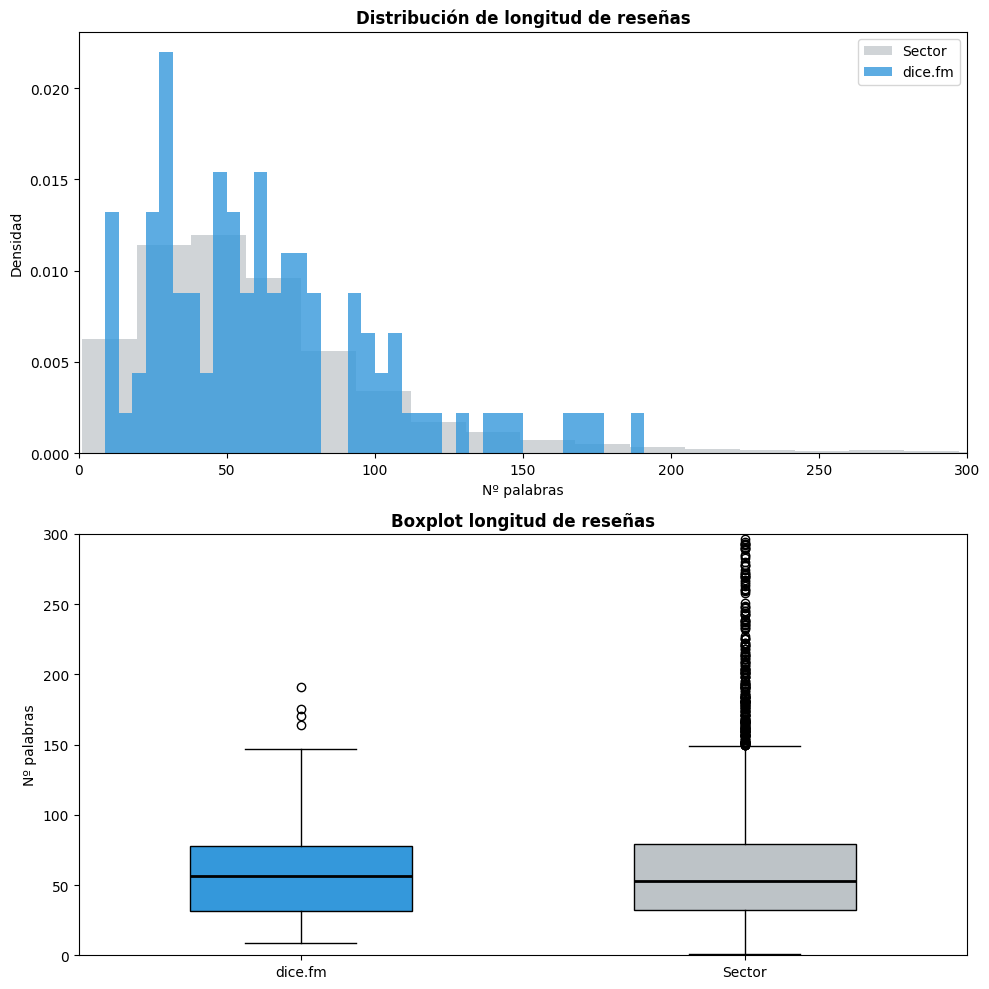

In [8]:
# Longitud de reseñas (palabras)
target_df['n_words'] = target_df['review'].astype(str).str.split().str.len()
sector_sin_target = sector_df[sector_df['company'] != TARGET].copy()
sector_sin_target['n_words'] = sector_sin_target['review'].astype(str).str.split().str.len()

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Histograma
axes[0].hist(sector_sin_target['n_words'], bins=40, color='#bdc3c7',
            alpha=0.7, label='Sector', density=True)
axes[0].hist(target_df['n_words'], bins=40, color='#3498db',
            alpha=0.8, label=TARGET, density=True)
axes[0].set_xlabel('Nº palabras')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de longitud de reseñas', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 300)

# Boxplot
data_box = [target_df['n_words'], sector_sin_target['n_words']]
bp = axes[1].boxplot(data_box, labels=[TARGET, 'Sector'],
                    patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#bdc3c7')
axes[1].set_ylabel('Nº palabras')
axes[1].set_title('Boxplot longitud de reseñas', fontweight='bold')
axes[1].set_ylim(0, 300)

# Estadisticas
print(f"Longitud media — {TARGET}: {target_df['n_words'].mean():.1f} palabras")
print(f"Longitud media — Sector:  {sector_sin_target['n_words'].mean():.1f} palabras")
print(f"Mediana — {TARGET}: {target_df['n_words'].median():.0f} palabras")
print(f"Mediana — Sector:  {sector_sin_target['n_words'].median():.0f} palabras")

plt.tight_layout()
plt.show()

#### 2. Top palabras más frecuentes (dice.fm)

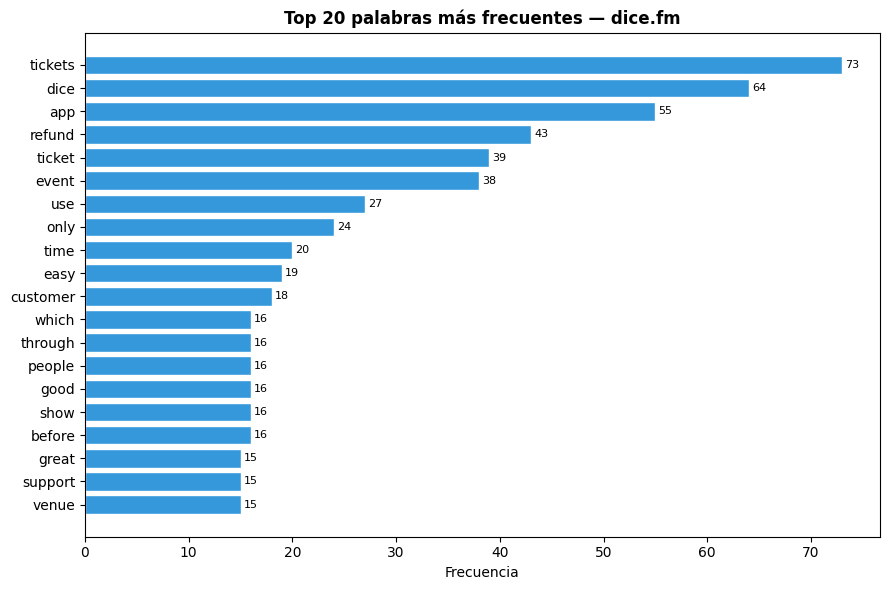

In [9]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','of','to','for','is','it',
    'was','my','i','with','that','this','at','not','they','have','had',
    'be','as','by','we','are','from','so','all','been','has','me','he',
    'she','you','our','their','were','its','if','out','no','up','what',
    'there','when','would','get','did','do','got','just','about','very',
    'his','her','more','one','than','can','will','could','your','some'
}

def top_words(texts, n=20):
    words = []
    for t in texts:
        for w in str(t).lower().split():
            w = w.strip('.,!?;:\'"()-')
            if len(w) > 2 and w not in STOPWORDS:
                words.append(w)
    return Counter(words).most_common(n)

top_target = top_words(target_df['review'], n=20)
words, counts = zip(*top_target)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(words[::-1], counts[::-1], color='#3498db', edgecolor='white')
ax.set_xlabel('Frecuencia')
ax.set_title(f'Top 20 palabras más frecuentes — {TARGET}', fontweight='bold')
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=8)
plt.tight_layout()
plt.show()

Simplemente por haber elegido el sector 'Events & Entertainment' y la empresa dice.fm se presupone que palabras como 'ticket', 'dice', 'event'.... van a aparecer con mucha frecuencia y quizás sería recomendable añadirlas al STOPWORDS.

## 5. Exploración de caracteres y limpieza de texto


In [10]:
sample = target_df['review'].astype(str)
print('Análisis de caracteres en reseñas de', TARGET,':')
print(f'  URLs presentes:        {sample.str.contains(r"http|www", case=False).sum()}')
print(f'  No-ASCII (emojis, símbolos, acentos...): {sample.str.contains(r"[^\x00-\x7F]").sum()}')
print(f'  Contienen números:     {sample.str.contains(r"\d").sum()}')
print(f'  HTML tags:             {sample.str.contains(r"<[a-z]").sum()}')
print(f'  Longitud media:        {sample.str.len().mean():.0f} caracteres')
print(f'  Longitud mediana:      {sample.str.len().median():.0f} caracteres')

Análisis de caracteres en reseñas de dice.fm :
  URLs presentes:        0
  No-ASCII (emojis, símbolos, acentos...): 28
  Contienen números:     28
  HTML tags:             0
  Longitud media:        348 caracteres
  Longitud mediana:      312 caracteres


He visto que hay reseñas en varios idiomas como por ejemplo en italiano (no todas están en ingles), por tanto, voy a utilizar una función de limpieza del texto que sea compatible con varios idiomas.

In [11]:
def clean_text(text):
    """Normaliza y limpia una reseña — compatible con cualquier idioma. Se conservan valores numéricos"""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)       # URLs
    text = re.sub(r'<[^>]+>', ' ', text)                # HTML tags
    text = re.sub(r'@\w+|#\w+', ' ', text)              # menciones y hashtags     
    text = re.sub(r'[^\w\s]', ' ', text)                # puntuación (conserva letras Unicode)
    text = re.sub(r'\s+', ' ', text).strip()            # espacios extra
    text = ' '.join(w for w in text.split() if len(w) > 2 or w.isdigit())
    return text

# Verificación
orig  = target_df['review'].iloc[0]
clean = clean_text(orig)
print('ORIGINAL:\n', orig[:300])
print('\nLIMPIO:\n', clean[:300])

ORIGINAL:
 I Clock DVA di Sheffield. Siamo alla fine degli anni '80. Alfieri dell'Industrial music. Consumai letteralmente il vinile "Thirst" redo del 1981 seguito da "Advantage" Poi li ho persi di vista intorno alla fine degli anni '90 Quasi 30 anni dopo riscopro un Signore armato di personal Computer:music, 

LIMPIO:
 clock dva sheffield siamo alla fine degli anni 80 alfieri dell industrial music consumai letteralmente vinile thirst redo del 1981 seguito advantage poi persi vista intorno alla fine degli anni 90 quasi 30 anni dopo riscopro signore armato personal computer music noise lights stories technologies ar


In [12]:
sector_df['clean_review'] = sector_df['review'].apply(clean_text)

# Descartar reseñas vacías tras limpieza
empty = sector_df['clean_review'].str.len() == 0
print(f'Reseñas descartadas (demasiado cortas): {empty.sum()}')
sector_df = sector_df[~empty].reset_index(drop=True)

target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)

print(f'Reseñas limpias — {TARGET}: {len(target_df)}')
print(f'Reseñas limpias — sector:  {len(sector_df):,}')

Reseñas descartadas (demasiado cortas): 0
Reseñas limpias — dice.fm: 100
Reseñas limpias — sector:  5,298


## 6. Análisis de Sentimiento
Utilizamos el modelo **DistilBERT multilingüe** fine-tuned para clasificación de sentimiento,
compatible con 27 idiomas (inglés, italiano, francés, alemán, español...).

Devuelve tres clases: `positive`, `neutral` y `negative`.


In [14]:
print(f'Cargando modelo: {SENT_MODEL} ...')
sent_pipe = pipeline(
    'text-classification',
    model=SENT_MODEL,
    truncation=True,
    max_length=512,
    device=-1   # CPU; cambiar a 0 si hay GPU disponible
)

def batch_sentiment(texts, pipe=sent_pipe, batch_size=64):
    """Aplica el pipeline de sentimiento en batches."""
    texts   = [str(t)[:2000] for t in texts]
    results = []
    for i in range(0, len(texts), batch_size):
        preds = pipe(texts[i:i+batch_size], truncation=True, max_length=512)
        results.extend(preds)
    return results

print('Pipeline listo')

Cargando modelo: lxyuan/distilbert-base-multilingual-cased-sentiments-student ...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pipeline listo


In [15]:
print(f'Procesando {len(sector_df):,} reseñas del sector...')
all_preds = batch_sentiment(sector_df['clean_review'].tolist())

sector_df['sentiment']   = [p['label'] for p in all_preds]
sector_df['is_positive'] = (sector_df['sentiment'] == 'positive').astype(int)

target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)

pct_t = target_df['is_positive'].mean() * 100
pct_s = comp_df['is_positive'].mean()   * 100
print(f'\n{"-"*45}')
print(f'% Positivo  {TARGET:<22}: {pct_t:.1f}%')
print(f'% Positivo  Sector (sin target): {pct_s:.1f}%')
print(f'{"-"*45}')

Procesando 5,298 reseñas del sector...

---------------------------------------------
% Positivo  dice.fm               : 43.0%
% Positivo  Sector (sin target): 46.8%
---------------------------------------------


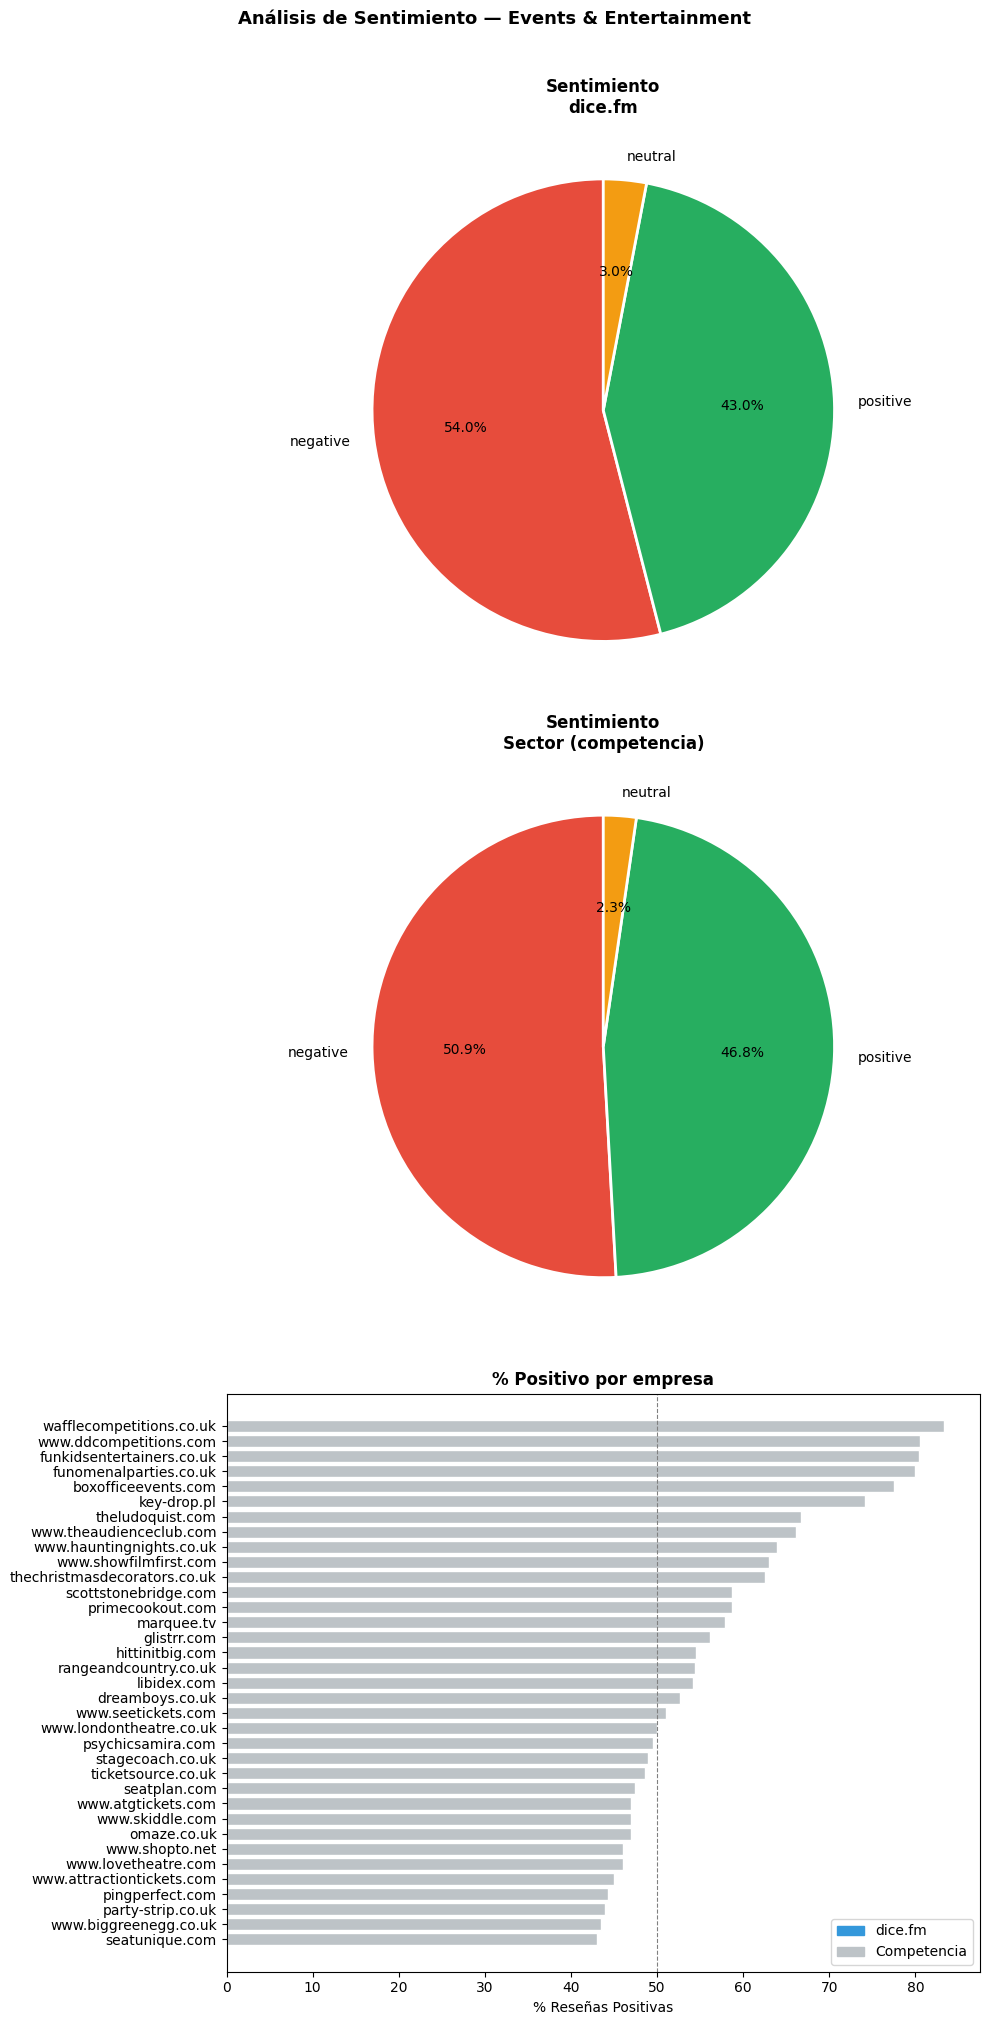

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 20))

def color_sentiment(label):
      if label == 'positive': return '#27ae60'
      if label == 'negative': return '#e74c3c'
      return '#f39c12'

# Pie TARGET
vc_t = target_df['sentiment'].value_counts()
pie_c_t =  [color_sentiment(l) for l in vc_t.index]
axes[0].pie(vc_t.values, labels=vc_t.index, colors=pie_c_t,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f'Sentimiento\n{TARGET}', fontweight='bold')

# Pie SECTOR
vc_s = comp_df['sentiment'].value_counts()
pie_c_s =  [color_sentiment(l) for l in vc_s.index]
axes[1].pie(vc_s.values, labels=vc_s.index, colors=pie_c_s,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentimiento\nSector (competencia)', fontweight='bold')

# Barras: % positivo por empresa
co_sent = (
    sector_df.groupby('company')['is_positive']
    .agg(pct_pos='mean', n='count')
    .query('n >= 30')
    .assign(pct_pos=lambda x: x['pct_pos'] * 100)
    .sort_values('pct_pos', ascending=True)
    .tail(35)
)
bar_c2 = ['#3498db' if c == TARGET else '#bdc3c7' for c in co_sent.index]
axes[2].barh(co_sent.index, co_sent['pct_pos'], color=bar_c2, edgecolor='white')
axes[2].axvline(50, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('% Reseñas Positivas')
axes[2].set_title('% Positivo por empresa', fontweight='bold')
p1 = mpatches.Patch(color='#3498db', label=TARGET)
p2 = mpatches.Patch(color='#bdc3c7', label='Competencia')
axes[2].legend(handles=[p1, p2])

plt.suptitle('Análisis de Sentimiento — Events & Entertainment',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
co_rank = (
    sector_df.groupby('company')
    .agg(pct_positivo=('is_positive', 'mean'),
        n_reviews=('review', 'count'))
    .query('n_reviews >= 30')
    .assign(pct_positivo=lambda x: (x['pct_positivo'] * 100).round(1))
    .sort_values('pct_positivo', ascending=False)
)
print('=== Ranking empresas por % reseñas positivas ===')
print(co_rank.to_string())
if TARGET in co_rank.index:
    rank = list(co_rank.index).index(TARGET) + 1
    print(f'\n{TARGET} → puesto {rank} de {len(co_rank)}')

=== Ranking empresas por % reseñas positivas ===
                                  pct_positivo  n_reviews
company                                                  
wafflecompetitions.co.uk                  83.3         30
www.ddcompetitions.com                    80.5         41
funkidsentertainers.co.uk                 80.4         46
funomenalparties.co.uk                    80.0         35
boxofficeevents.com                       77.6         49
key-drop.pl                               74.2         93
theludoquist.com                          66.7         39
www.theaudienceclub.com                   66.2         65
www.hauntingnights.co.uk                  63.9         36
www.showfilmfirst.com                     63.0         81
thechristmasdecorators.co.uk              62.5         32
scottstonebridge.com                      58.7         63
primecookout.com                          58.7         46
marquee.tv                                57.8         83
glistrr.com            

## 7. Topic Modeling — NMF
Aplicamos **TF-IDF + NMF** sobre todas las reseñas del sector para obtener temas comparables entre empresas.


Se ha optado por **TF-IDF + NMF** frente a BERTopic por cuatro razones principales:

1. **Tamaño del corpus**: BERTopic requiere grandes volúmenes de datos para que UMAP + HDBSCAN
    generen clusters estables. Con 100 reseñas, HDBSCAN tiende a clasificar una parte significativa
    de documentos como ruido, degradando la interpretabilidad. TF-IDF + NMF es más robusto con
    corpus pequeños.

2. **Interpretabilidad**: NMF produce temas directamente legibles como combinaciones de palabras
    con pesos positivos. BERTopic opera en espacio de embeddings de alta dimensión, lo que requiere
    herramientas adicionales para explicar la asignación de documentos a temas.

3. **Coste computacional**: BERTopic añade un segundo modelo transformer (embeddings) + UMAP +
    HDBSCAN al pipeline, que ya incluye DistilBERT para sentimiento. El coste adicional no está
    justificado para el tamaño del corpus.

4. **Adecuación al objetivo**: El análisis busca identificar qué temas concentran la insatisfacción,
    no descubrir estructuras semánticas complejas. TF-IDF + NMF responde a esa pregunta de forma
    clara y reproducible.

In [18]:
print('Construyendo matriz TF-IDF del sector...')
tfidf_vec = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.85,
    stop_words='english',          # cubre solo inglés; stopwords de otros idiomas pueden persistir
    ngram_range=(1, 2),
    token_pattern=r'(?u)\b[^\W\d_]{3,}\b'   # Unicode: captura letras acentuadas (ej. italiano, francés)
)
tfidf_matrix = tfidf_vec.fit_transform(sector_df['clean_review'])
feat_names   = tfidf_vec.get_feature_names_out()
print(f'Vocabulario: {len(feat_names):,} términos | Matriz: {tfidf_matrix.shape}')

print(f'Ajustando NMF con {N_TOPICS} componentes...')
nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=500, l1_ratio=0.1)
W   = nmf.fit_transform(tfidf_matrix)   # doc × topic
H   = nmf.components_                   # topic × word

sector_df['topic']        = W.argmax(axis=1)
sector_df['topic_weight'] = W.max(axis=1)

target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)
print('NMF completado')

Construyendo matriz TF-IDF del sector...
Vocabulario: 5,000 términos | Matriz: (5298, 5000)
Ajustando NMF con 6 componentes...
NMF completado


In [19]:
print('=== TOPICS detectados (sector Events & Entertainment) ===')
for i, row in enumerate(H):
    top_idx   = row.argsort()[-TOP_WORDS:][::-1]
    top_words = ' | '.join(feat_names[j] for j in top_idx)
    print(f'Topic {i}: {top_words}')
print()

print(f'Distribución de topics en {TARGET}:')
print(target_df['topic'].value_counts().sort_index())

=== TOPICS detectados (sector Events & Entertainment) ===
Topic 0: refund | ticket | email | money | days | received | order | event | didn | paid
Topic 1: great | good | time | really | amazing | party | people | recommend | like | night
Topic 2: date experience | date | experience | experience january | january | march | april | experience november | experience october | october
Topic 3: service | customer | customer service | issue | excellent | helpful | help | great | company | support
Topic 4: easy | use | easy use | site | website | quick | book | easy book | process | good
Topic 5: tickets | buy | bought | seats | bought tickets | buy tickets | event | buying | sold | available

Distribución de topics en dice.fm:
topic
0    25
1    22
2     1
3     7
4    18
5    27
Name: count, dtype: int64


**Los topics dominantes en dice.fm son compra de entradas y reembolsos — ya apunta a que los problemas operativos son el núcleo de las reseñas negativas.**

Topic 2 — es el más débil. Las palabras clave (experience january, experience october, etc.) sugieren que NMF agrupó reseñas que mencionan fechas concretas de eventos, no un tema semántico real. Tiene solo 1 reseña en dice.fm, así que no afecta al análisis de la empresa.

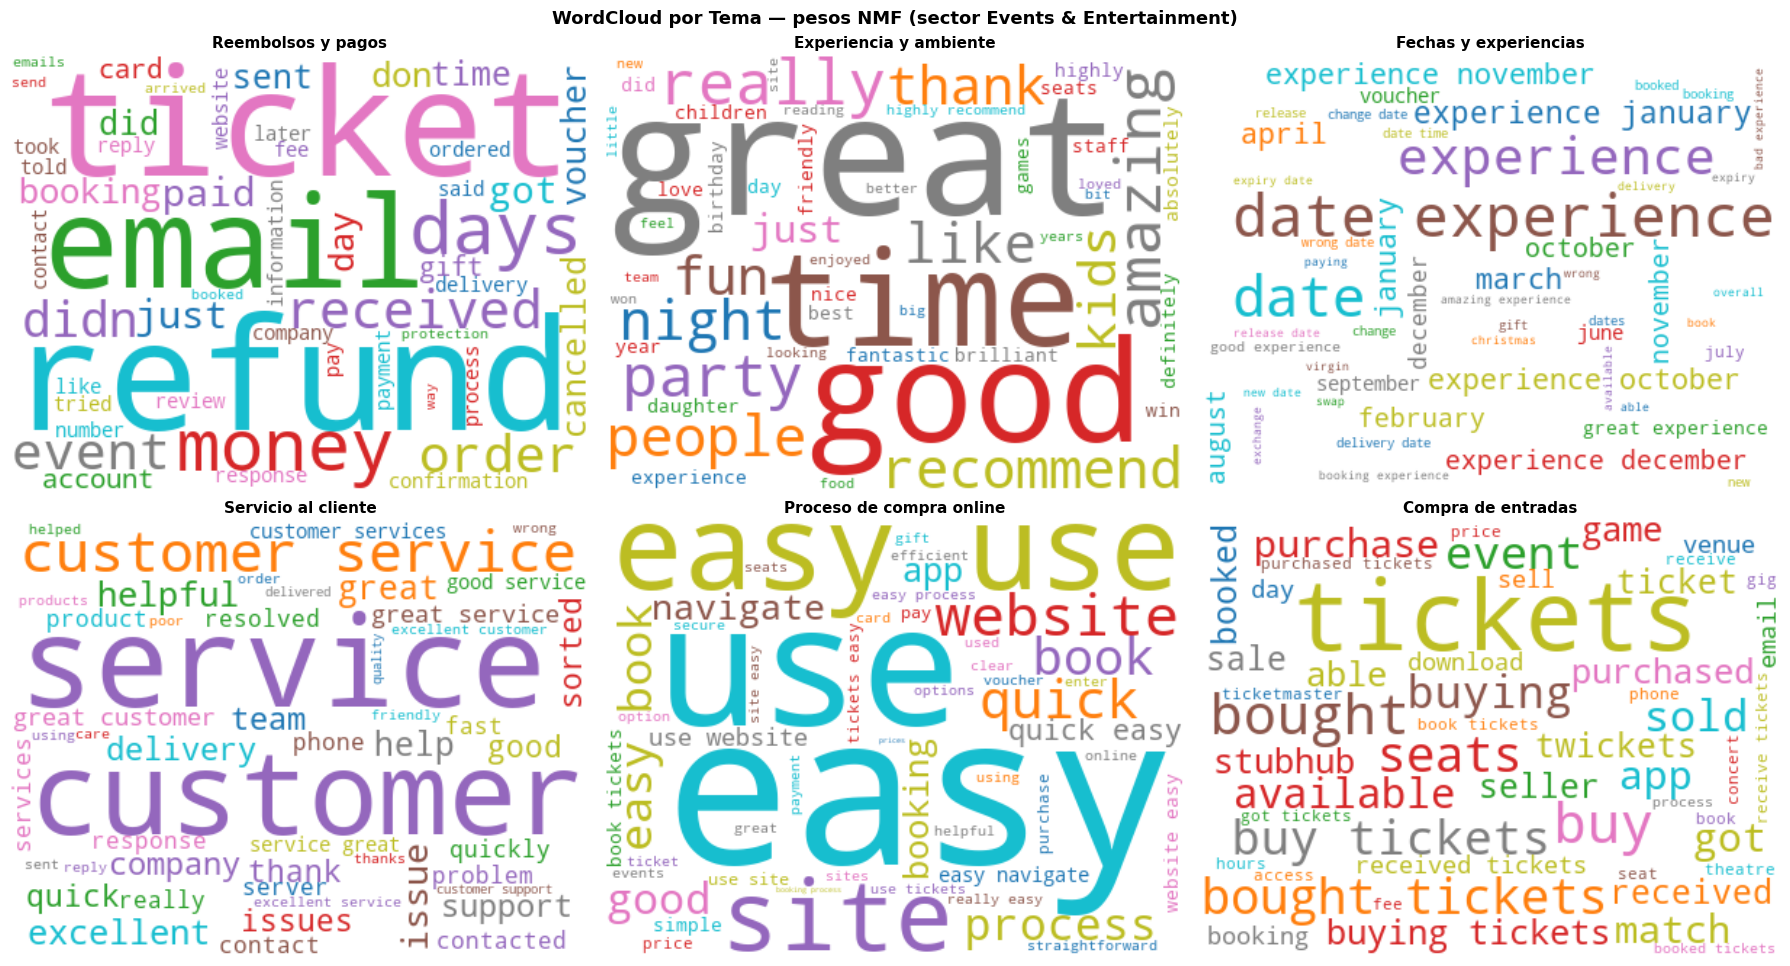

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for topic_idx, ax in enumerate(axes):
    weights = dict(zip(feat_names, H[topic_idx]))
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap='tab10',
        max_words=50,
        prefer_horizontal=0.9
    ).generate_from_frequencies(weights)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{TOPIC_LABELS[topic_idx]}', fontweight='bold', fontsize=11)
    ax.axis('off')

plt.suptitle('WordCloud por Tema — pesos NMF (sector Events & Entertainment)',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Aplica etiquetas (actualiza TOPIC_LABELS arriba si es necesario)
sector_df['topic_label'] = sector_df['topic'].map(TOPIC_LABELS)
target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)

print(f'Topics en {TARGET}:')
for lbl, cnt in target_df['topic_label'].value_counts().items():
    print(f'  {lbl}: {cnt} reseñas ({cnt/len(target_df)*100:.1f}%)')

Topics en dice.fm:
  Compra de entradas: 27 reseñas (27.0%)
  Reembolsos y pagos: 25 reseñas (25.0%)
  Experiencia y ambiente: 22 reseñas (22.0%)
  Proceso de compra online: 18 reseñas (18.0%)
  Servicio al cliente: 7 reseñas (7.0%)
  Fechas y experiencias: 1 reseñas (1.0%)


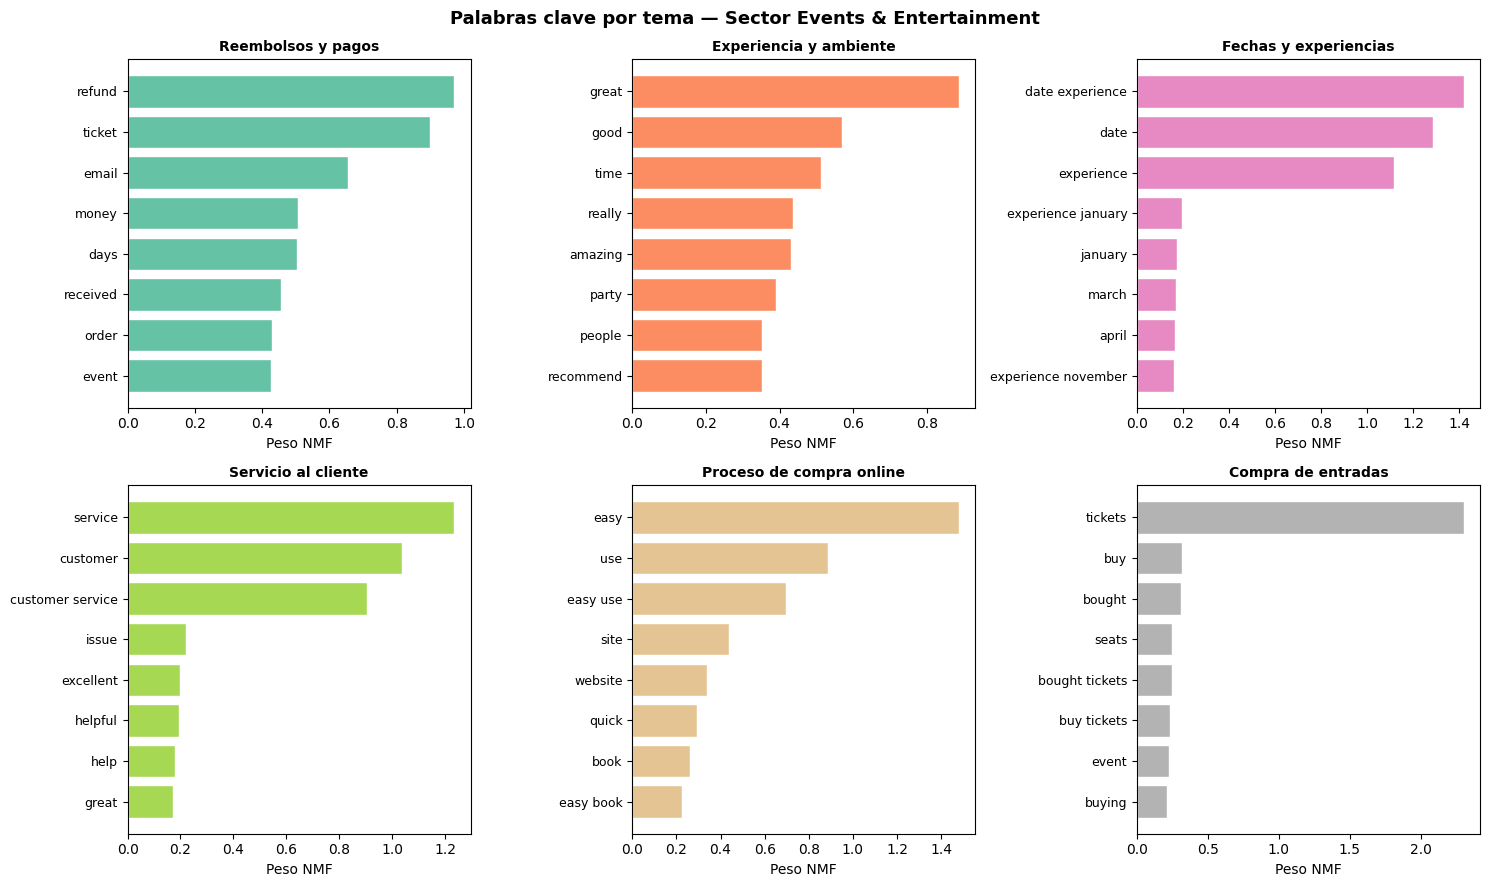

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes  = axes.flatten()
cmap  = plt.cm.Set2(np.linspace(0, 1, N_TOPICS))

for t_idx in range(N_TOPICS):
    ax     = axes[t_idx]
    vec    = H[t_idx]
    top_i  = vec.argsort()[-8:][::-1]
    words  = [feat_names[j] for j in top_i]
    wts    = [vec[j] for j in top_i]
    ax.barh(words[::-1], wts[::-1], color=cmap[t_idx], edgecolor='white')
    ax.set_title(TOPIC_LABELS.get(t_idx, f'Topic {t_idx}'), fontweight='bold', fontsize=10)
    ax.set_xlabel('Peso NMF')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle(f'Palabras clave por tema — Sector {CAT}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

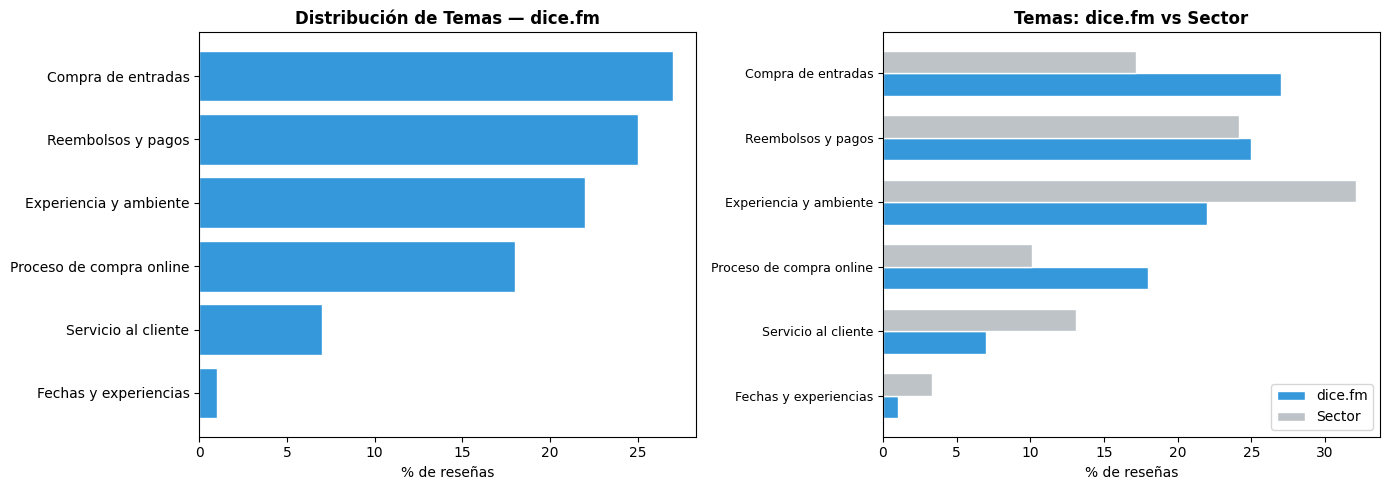

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución TARGET
t_dist = (target_df['topic_label'].value_counts() / len(target_df) * 100).sort_values(ascending=True)
axes[0].barh(t_dist.index, t_dist.values, color='#3498db', edgecolor='white')
axes[0].set_xlabel('% de reseñas')
axes[0].set_title(f'Distribución de Temas — {TARGET}', fontweight='bold')

# TARGET vs SECTOR
c_dist = comp_df['topic_label'].value_counts() / len(comp_df) * 100
cmp_df = pd.DataFrame({
    TARGET: target_df['topic_label'].value_counts() / len(target_df) * 100,
    'Sector': c_dist
}).fillna(0).sort_values(TARGET, ascending=True)

y = np.arange(len(cmp_df))
w = 0.35
axes[1].barh(y - w/2, cmp_df[TARGET],   w, label=TARGET,   color='#3498db', edgecolor='white')
axes[1].barh(y + w/2, cmp_df['Sector'], w, label='Sector', color='#bdc3c7', edgecolor='white')
axes[1].set_yticks(y)
axes[1].set_yticklabels(cmp_df.index, fontsize=9)
axes[1].set_xlabel('% de reseñas')
axes[1].set_title(f'Temas: {TARGET} vs Sector', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Sentimiento por Tema


In [24]:
sent_by_topic_t = (
    target_df.groupby('topic_label')['is_positive']
    .agg(pct_pos='mean', n='count')
    .assign(pct_pos=lambda x: (x['pct_pos'] * 100).round(1),
            pct_neg=lambda x: (100 - x['pct_pos']).round(1))
    .sort_values('pct_pos', ascending=False)
)
sent_by_topic_s = (
    comp_df.groupby('topic_label')['is_positive']
    .agg(pct_pos='mean', n='count')
    .assign(pct_pos=lambda x: (x['pct_pos'] * 100).round(1))
)
print(f'=== Sentimiento por tema — {TARGET} ===')
print(sent_by_topic_t[['pct_pos', 'pct_neg', 'n']].to_string())

=== Sentimiento por tema — dice.fm ===
                          pct_pos  pct_neg   n
topic_label                                   
Fechas y experiencias       100.0      0.0   1
Proceso de compra online     88.9     11.1  18
Experiencia y ambiente       50.0     50.0  22
Compra de entradas           44.4     55.6  27
Servicio al cliente          14.3     85.7   7
Reembolsos y pagos            8.0     92.0  25


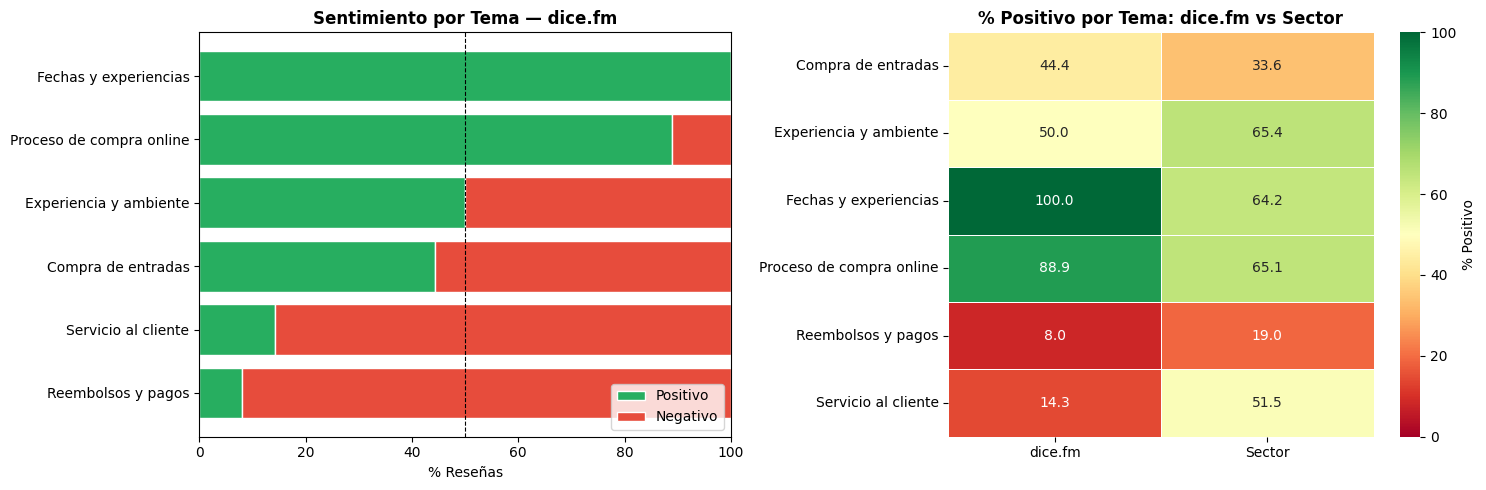

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar TARGET
st_sorted = sent_by_topic_t.sort_values('pct_pos')
axes[0].barh(st_sorted.index, st_sorted['pct_pos'], color='#27ae60', label='Positivo', edgecolor='white')
axes[0].barh(st_sorted.index, st_sorted['pct_neg'], left=st_sorted['pct_pos'],
            color='#e74c3c', label='Negativo', edgecolor='white')
axes[0].axvline(50, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('% Reseñas')
axes[0].set_title(f'Sentimiento por Tema — {TARGET}', fontweight='bold')
axes[0].legend(loc='lower right')

# Heatmap TARGET vs SECTOR
hm_data = pd.DataFrame({
    TARGET: sent_by_topic_t['pct_pos'],
    'Sector': sent_by_topic_s['pct_pos']
})

missing = hm_data[hm_data.isna().any(axis=1)].index.tolist()
if missing:
    print(f'Topics sin datos en un lado de la comparativa (se muestran como 0): {missing}')

hm_data = hm_data.fillna(0)

sns.heatmap(hm_data, ax=axes[1], annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% Positivo'})
axes[1].set_title(f'% Positivo por Tema: {TARGET} vs Sector', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 9. Comparativa con la competencia


In [26]:
# Sentimiento por tema: dice.fm vs media del sector
comp_summary = pd.DataFrame({
    TARGET:   sent_by_topic_t['pct_pos'],
    'Sector': sent_by_topic_s['pct_pos']
}).dropna().round(1)
comp_summary['gap'] = (comp_summary[TARGET] - comp_summary['Sector']).round(1)

print(f'=== {TARGET} vs Media del Sector (% positivo) ===')
print(comp_summary.to_string())
print()
print('FORTALEZAS (mejor que el sector):')
for topic, row in comp_summary[comp_summary['gap'] > 0].sort_values('gap', ascending=False).iterrows():
    print(f'  ▲ {topic}: {row[TARGET]}% vs {row["Sector"]}% sector (+{row["gap"]}%)')
print('\nDEBILIDADES / ÁREAS DE MEJORA:')
for topic, row in comp_summary[comp_summary['gap'] < 0].sort_values('gap').iterrows():
    print(f'  ▼ {topic}: {row[TARGET]}% vs {row["Sector"]}% sector ({row["gap"]}%)')

=== dice.fm vs Media del Sector (% positivo) ===
                          dice.fm  Sector   gap
topic_label                                    
Compra de entradas           44.4    33.6  10.8
Experiencia y ambiente       50.0    65.4 -15.4
Fechas y experiencias       100.0    64.2  35.8
Proceso de compra online     88.9    65.1  23.8
Reembolsos y pagos            8.0    19.0 -11.0
Servicio al cliente          14.3    51.5 -37.2

FORTALEZAS (mejor que el sector):
  ▲ Fechas y experiencias: 100.0% vs 64.2% sector (+35.8%)
  ▲ Proceso de compra online: 88.9% vs 65.1% sector (+23.8%)
  ▲ Compra de entradas: 44.4% vs 33.6% sector (+10.8%)

DEBILIDADES / ÁREAS DE MEJORA:
  ▼ Servicio al cliente: 14.3% vs 51.5% sector (-37.2%)
  ▼ Experiencia y ambiente: 50.0% vs 65.4% sector (-15.4%)
  ▼ Reembolsos y pagos: 8.0% vs 19.0% sector (-11.0%)


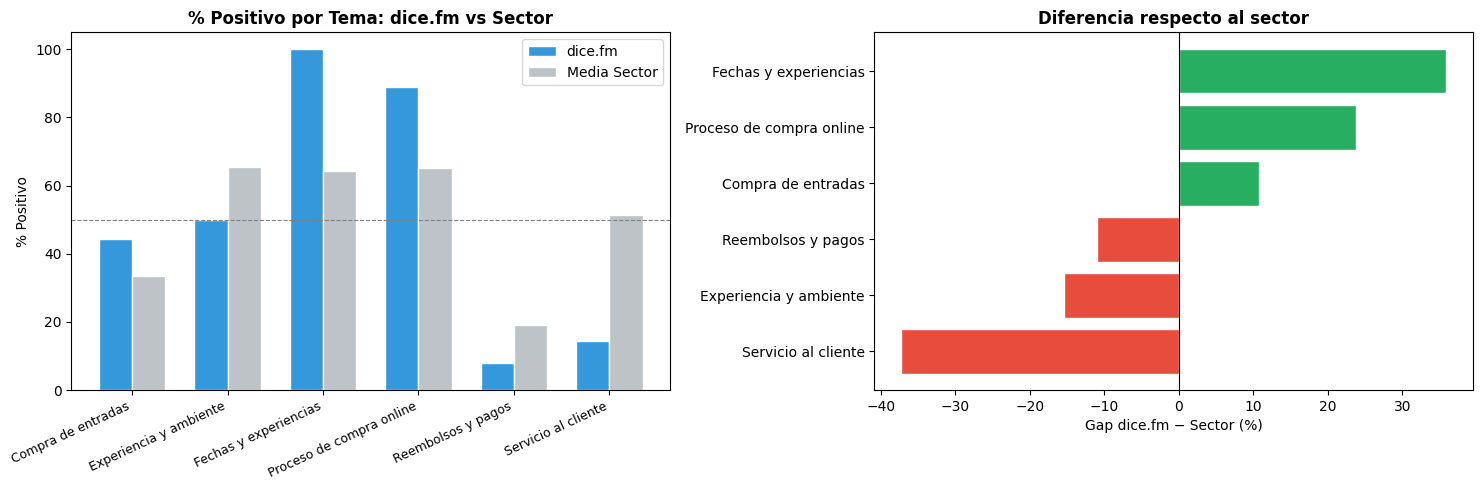

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar: target vs sector por tema
topics_list = comp_summary.index.tolist()
x = np.arange(len(topics_list))
w = 0.35
axes[0].bar(x - w/2, comp_summary[TARGET], w, label=TARGET, color='#3498db', edgecolor='white')
axes[0].bar(x + w/2, comp_summary['Sector'], w, label='Media Sector', color='#bdc3c7', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(topics_list, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('% Positivo')
axes[0].axhline(50, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title(f'% Positivo por Tema: {TARGET} vs Sector', fontweight='bold')
axes[0].legend()

# GAP chart
gap_sorted = comp_summary['gap'].sort_values()
colors_gap = ['#27ae60' if v >= 0 else '#e74c3c' for v in gap_sorted.values]
axes[1].barh(gap_sorted.index, gap_sorted.values, color=colors_gap, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel(f'Gap {TARGET} − Sector (%)')
axes[1].set_title(f'Diferencia respecto al sector', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Reseñas negativas representativas por tema


In [28]:
print(f'=== Reseñas negativas representativas de {TARGET} ===\n')
for topic_idx in range(N_TOPICS):
    lbl = TOPIC_LABELS.get(topic_idx, f'Topic {topic_idx}')
    neg = target_df[
        (target_df['topic'] == topic_idx) &
        (target_df['sentiment'] == 'negative')
    ]['review']
    if len(neg) == 0:
        continue
    print(f'--- {lbl} ({len(neg)} reseñas negativas) ---')
    for rev in neg.sample(min(2, len(neg)), random_state=42):
        print(f'  "{str(rev)[:280]}"')
    print()

=== Reseñas negativas representativas de dice.fm ===

--- Reembolsos y pagos (20 reseñas negativas) ---
  "We initially had trouble using the presale code for the jbalvin Amazon music show. Once I entered my presale code the page crashed. I’m not sure if crash it the correct word but my friends and I were booted out one we entered our code. We were able to be linked to the page hours "
  "The venue didn’t let us in because we didn’t have a passport to prove our teenage son’s age. There was no indication during the booking process that he would need ID. We’ve taken him to 14+ gigs before with no problem, including ones booked through Dice last year. It was meant to"

--- Experiencia y ambiente (11 reseñas negativas) ---
  "The venue that night, on a summer evening, was like a furnace. Enlosed, packed and no AC. Stayed only for less than an hour. Im a post-op/full transwoman. I gave my old NY ID to the security guy. Looked at me a few times then to my old ID. Then asked me to get line to

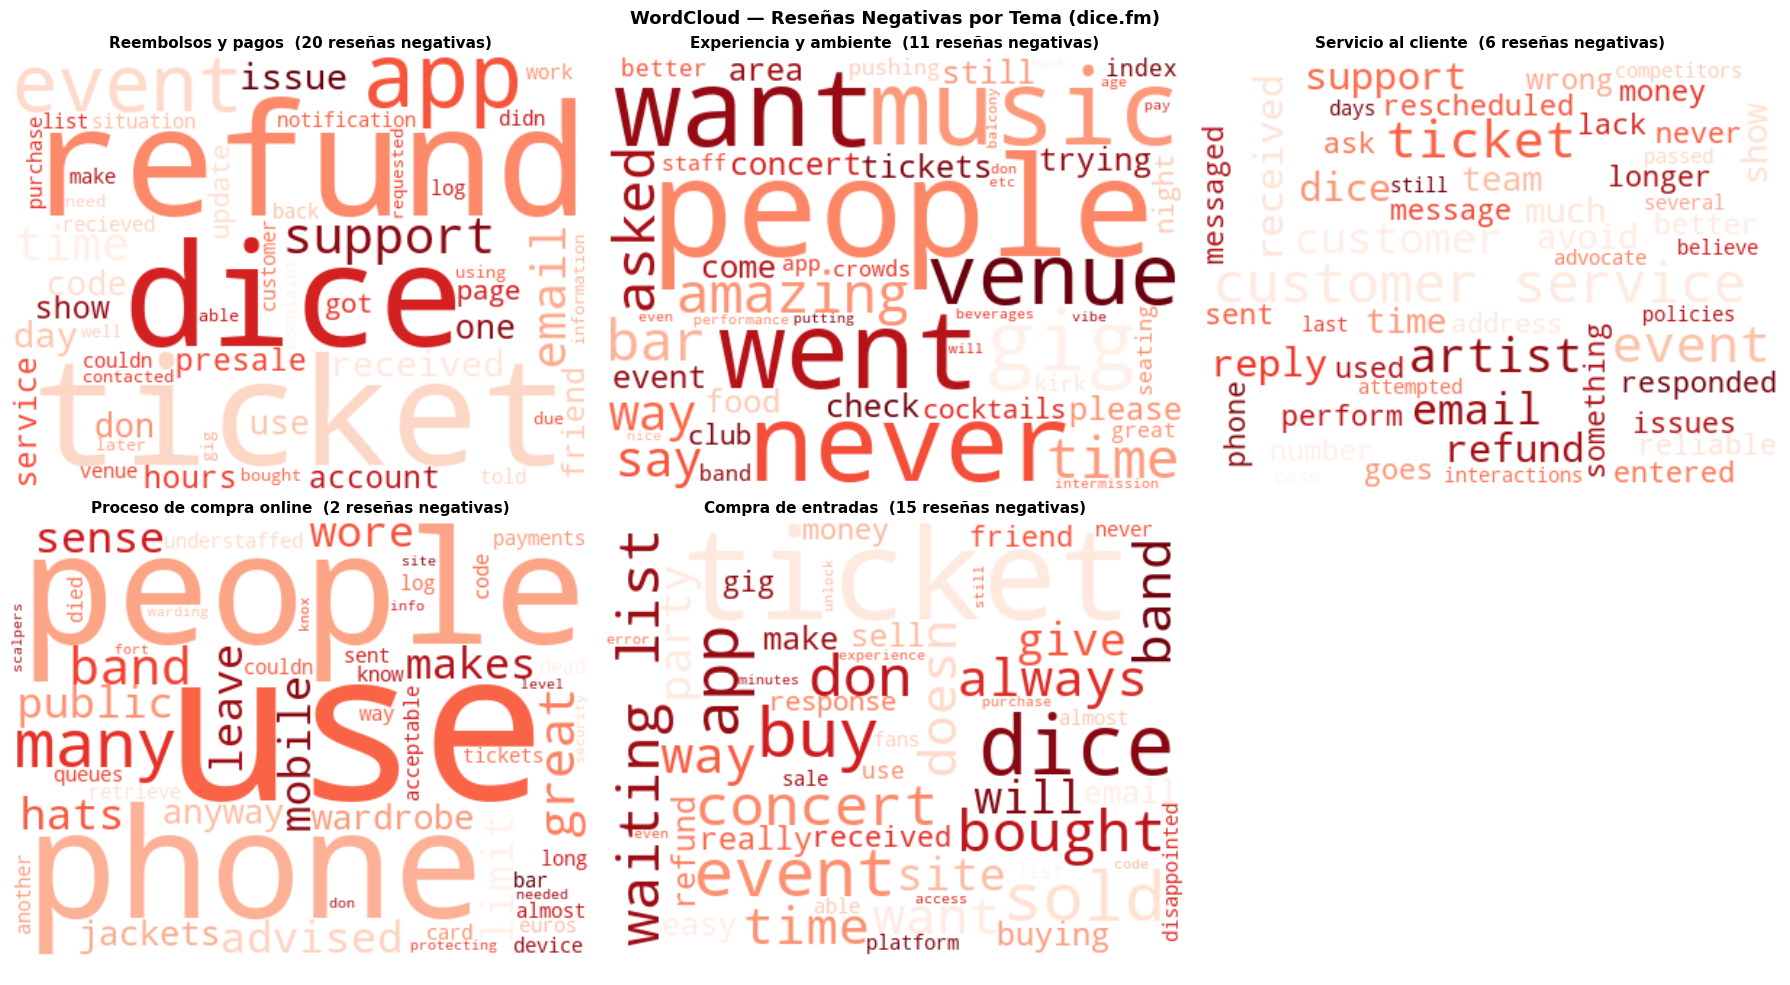

In [29]:
topics_to_show = [l for l in TOPIC_LABELS.values() if l != 'Fechas y experiencias']
neg_reviews = target_df[target_df['sentiment'] == 'negative']

cols = 3
rows = -(-len(topics_to_show) // cols)  # ceil division
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, label in enumerate(topics_to_show):
    reviews = neg_reviews[neg_reviews['topic_label'] == label]['clean_review']
    if len(reviews) == 0:
        axes[i].axis('off')
        continue
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap='Reds',
        max_words=50,
        prefer_horizontal=0.9
    ).generate(' '.join(reviews))
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{label}  ({len(reviews)} reseñas negativas)',
                    fontweight='bold', fontsize=11)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'WordCloud — Reseñas Negativas por Tema ({TARGET})',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Representa lo que dicen los usuarios insatisfechos por topic.

## 11. Conclusiones

### Contexto del análisis
Se han analizado **100 reseñas de dice.fm** en el contexto del sector *Events & Entertainment*
(5,298 reseñas, 76 empresas) usando dos técnicas de NLP:
- **Análisis de sentimiento** con DistilBERT multilingüe
(`lxyuan/distilbert-base-multilingual-cased-sentiments-student`), compatible con las reseñas en inglés, italiano y francés presentes en el dataset.
- **Topic Modeling** con TF-IDF + NMF (6 temas), aplicado sobre el sector completo para obtener temas comparables
entre empresas.

---

### Sentimiento global
dice.fm obtiene un **43.0% de reseñas positivas**, frente al **46.8% de media del sector**,
situándose ligeramente por debajo de sus competidores. Esta diferencia global, sin embargo,
oculta disparidades importantes entre temas.

---

### Fortalezas identificadas

**Proceso de compra online (+23.8% sobre el sector)**
Es el punto más diferenciador de dice.fm. Con un 88.9% de reseñas positivas frente al 65.1%
del sector, los usuarios valoran especialmente la usabilidad de la app y la fluidez del proceso
de reserva. Constituye una ventaja competitiva clara.

**Compra de entradas (+10.8% sobre el sector)**
La disponibilidad y gestión de entradas también supera a la competencia (44.4% vs 33.6%),
aunque con margen de mejora dado que más de la mitad de las reseñas en este tema son negativas.

---

### Áreas críticas de mejora

**Reembolsos y pagos — el problema más grave**
Es el tema con mayor volumen de reseñas (25% del total) y el peor valorado: solo el **8.0%
son positivas**, frente al 19.0% del sector. Las reseñas negativas describen de forma recurrente
fallos en la gestión de reembolsos, ausencia de respuesta del soporte y situaciones de pérdida
económica sin resolución. Es la principal fuente de insatisfacción de los usuarios.

**Servicio al cliente — mayor gap con el sector (-37.2%)**
Con un 14.3% de reseñas positivas frente al 51.5% sectorial, este es el gap competitivo más
amplio. Los usuarios describen falta de empatía, tickets sin respuesta y resolución deficiente
de incidencias. Aunque solo representa el 7% de las reseñas, su impacto reputacional es alto
dado el tono de las valoraciones.

**Experiencia en evento (-15.4% sobre el sector)**
El 50% de positividad en este tema, frente al 65.4% del sector, refleja quejas relacionadas
con condiciones en los venues (temperatura, aforo, acceso). Al ser un aspecto parcialmente
fuera del control directo de dice.fm, el margen de actuación es limitado, aunque una
comunicación más clara sobre las condiciones del evento podría mitigar parte de la insatisfacción.

---

### Conclusión general

> dice.fm destaca como plataforma de compra — su app y proceso de reserva están por encima
> del sector — pero pierde la confianza del usuario en el postventa. La brecha entre la
> experiencia de compra (valorada positivamente) y la gestión de problemas (reembolsos,
> atención al cliente) es el principal factor que lastra su posición competitiva.
> Mejorar los tiempos de respuesta del soporte y revisar la política de reembolsos son
> las acciones con mayor impacto potencial sobre la satisfacción global.
